# Regression by Minimizing Absolute Deviation — Complete Experimental Workflow

This notebook runs the project from data preparation through OLS/LAD fitting, controlled experiments, validation, focused visualizations, and generated outputs.

The four retained visualizations are:
1. OLS vs LAD under contaminated responses.
2. SSE vs contamination.
3. SAE vs contamination.
4. HBK multivariate residual comparison.


## Regression objectives

For residuals

$$
r_i = y_i - x_i^T\beta,
$$

Ordinary Least Squares minimizes

$$
\min_{\beta}\sum_{i=1}^{n} r_i^2,
$$

while Least Absolute Deviations minimizes

$$
\min_{\beta}\sum_{i=1}^{n}|r_i|.
$$


In [1]:
import pandas as pd
from IPython.display import Image, display

from absolute_deviation.data import DATASETS, load_dataset
from absolute_deviation.experiments import (
    FIGURE_DIR,
    RESULT_DIR,
    run_contamination_experiment,
    run_error_distribution_experiment,
    run_original_data,
    run_runtime_benchmark,
    validate_lad_solver,
)
from absolute_deviation.plotting import generate_all_figures


## 1. Data preparation


In [2]:
dataset_rows = []
for name in DATASETS:
    X, y, predictors = load_dataset(name)
    dataset_rows.append({
        "dataset": name,
        "observations": len(y),
        "predictors": X.shape[1],
        "predictor_names": ", ".join(predictors),
    })

dataset_summary = pd.DataFrame(dataset_rows)
display(dataset_summary)


,dataset,observations,predictors,predictor_names
0,boston_housing,506,12,"CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD,..."
1,concrete_strength,1030,8,"Cement, BlastFurnaceSlag, FlyAsh, Water, Super..."
2,hbk,75,3,"X1, X2, X3"


## 2. Fit OLS and LAD on the empirical datasets


In [3]:
original_metrics, original_coefficients = run_original_data()
display(original_metrics[["dataset", "model", "SSE", "SAE"]])
display(original_coefficients)


,dataset,model,SSE,SAE
0,boston_housing,OLS,11349.418808,1698.290859
1,boston_housing,LAD,12469.793173,1611.011000
2,concrete_strength,OLS,110428.156817,8461.346375
3,concrete_strength,LAD,119464.579642,8289.485903
4,hbk,OLS,359.485726,103.468960
5,hbk,LAD,587.732546,86.742870


,dataset,model,term,estimate
0,boston_housing,OLS,Intercept,41.617270
1,boston_housing,OLS,CRIM,-0.121389
2,boston_housing,OLS,ZN,0.046963
3,boston_housing,OLS,INDUS,0.013468
4,boston_housing,OLS,CHAS,2.839993
5,boston_housing,OLS,NOX,-18.758022
6,boston_housing,OLS,RM,3.658119
7,boston_housing,OLS,AGE,0.003611
8,boston_housing,OLS,DIS,-1.490754
9,boston_housing,OLS,RAD,0.289405


## 3. Controlled large-response-error experiment

The controlled experiment adds increasingly large response errors while keeping the predictor design fixed. SSE and SAE are evaluated against the uncontaminated responses so the fitted models can be compared against the clean relationship.


In [4]:
contamination_metrics, contamination_shifts = run_contamination_experiment()

contamination_summary = (
    contamination_metrics
    .groupby(["contamination_fraction", "model"], as_index=False)[["SSE", "SAE"]]
    .mean()
)
display(contamination_summary)


,contamination_fraction,model,SSE,SAE
0,0.00,LAD,182.122968,145.663320
1,0.00,OLS,180.327505,146.546746
2,0.05,LAD,182.037211,145.839431
3,0.05,OLS,834.461729,314.679226
4,0.10,LAD,182.255068,146.184803
5,0.10,OLS,1442.425065,422.602621
6,0.20,LAD,183.746162,147.356557
7,0.20,OLS,3500.582570,658.179060


## 4. Error-distribution experiment


In [5]:
distribution_results = run_error_distribution_experiment()

distribution_summary = (
    distribution_results
    .groupby(["distribution", "model"], as_index=False)
    [["SSE", "SAE", "coefficient_error_l2"]]
    .median()
)
display(distribution_summary)


,distribution,model,SSE,SAE,coefficient_error_l2
0,cauchy,LAD,36618.163777,677.088736,0.267037
1,cauchy,OLS,35943.810534,830.185744,2.497144
2,contaminated_normal,LAD,1444.597511,216.386353,0.184862
3,contaminated_normal,OLS,1423.420948,224.566884,0.472607
4,laplace,LAD,143.129097,103.909445,0.124388
5,laplace,OLS,140.179326,105.021520,0.162644
6,normal,LAD,148.282634,117.174284,0.186731
7,normal,OLS,145.076526,117.773801,0.153228


## 5. Runtime benchmark


In [6]:
runtime_results = run_runtime_benchmark()

runtime_summary = (
    runtime_results
    .groupby(["n", "p", "model"], as_index=False)["runtime_seconds"]
    .median()
)
display(runtime_summary)


,n,p,model,runtime_seconds
0,50,1,LAD,0.002151
1,50,1,OLS,0.000128
2,50,3,LAD,0.002145
3,50,3,OLS,0.000047
4,50,5,LAD,0.002263
5,50,5,OLS,0.000054
6,100,1,LAD,0.002904
7,100,1,OLS,0.000045
8,100,3,LAD,0.003072
9,100,3,OLS,0.000054


## 6. Solver validation


In [7]:
validation_results = validate_lad_solver()
display(validation_results)


,example,ols_sse,lad_sse,ols_sae,lad_sae,ols_sse_is_minimum_against_lad,lad_sae_is_minimum_against_ols
0,1,3.621429e+02,676.0,4.085714e+01,26.0,True,True
1,2,9.860761e-32,0.0,4.440892e-16,0.0,True,True


## 7. Focused visualizations

Only the four figures that directly support the main OLS–LAD comparison are retained.


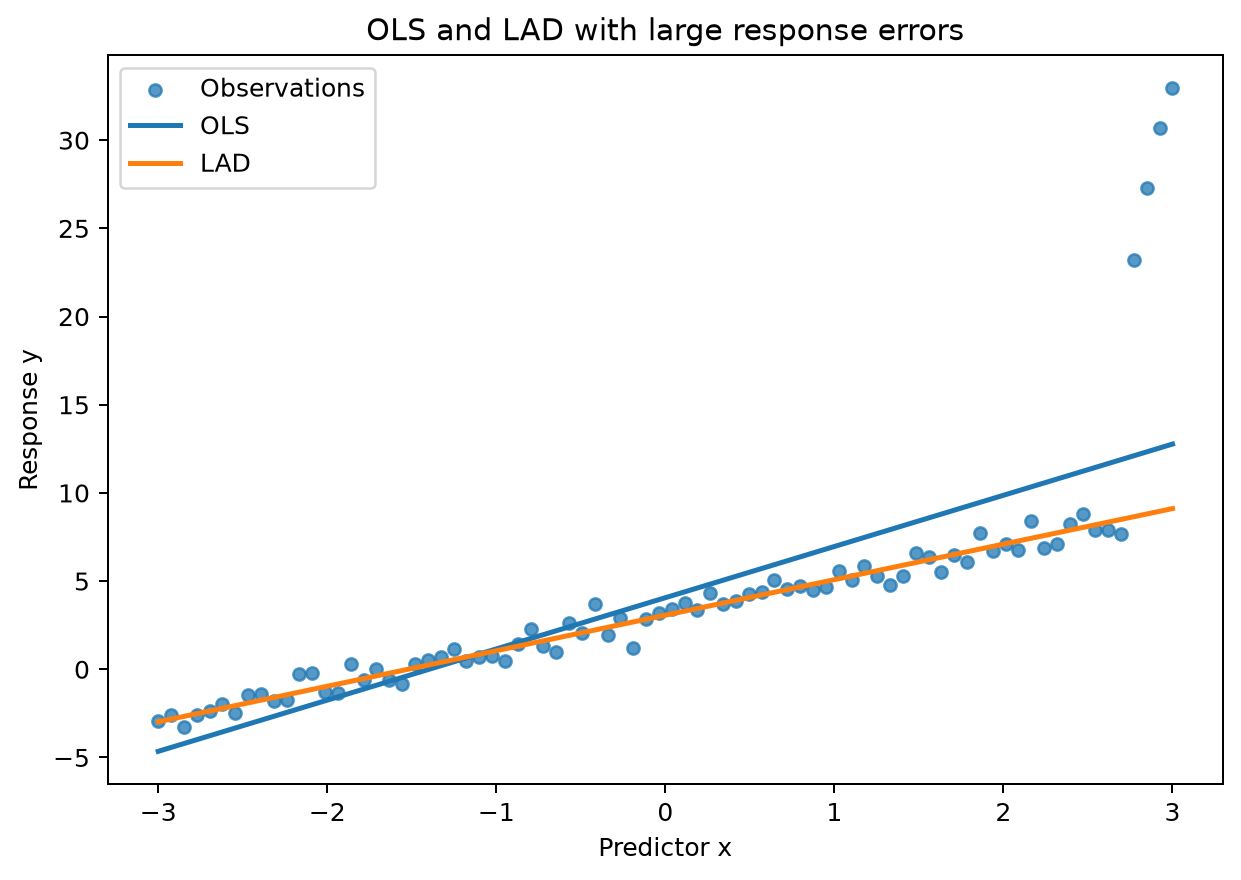

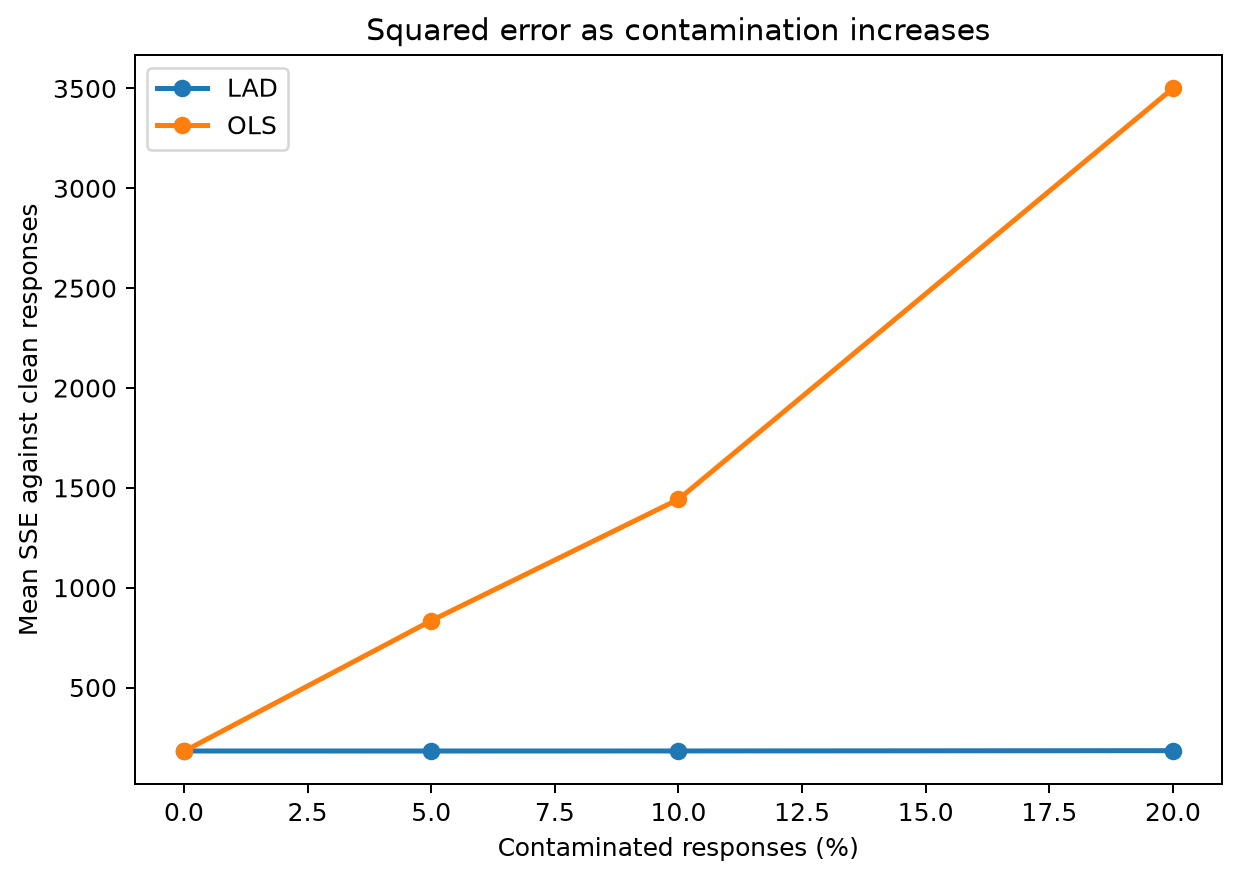

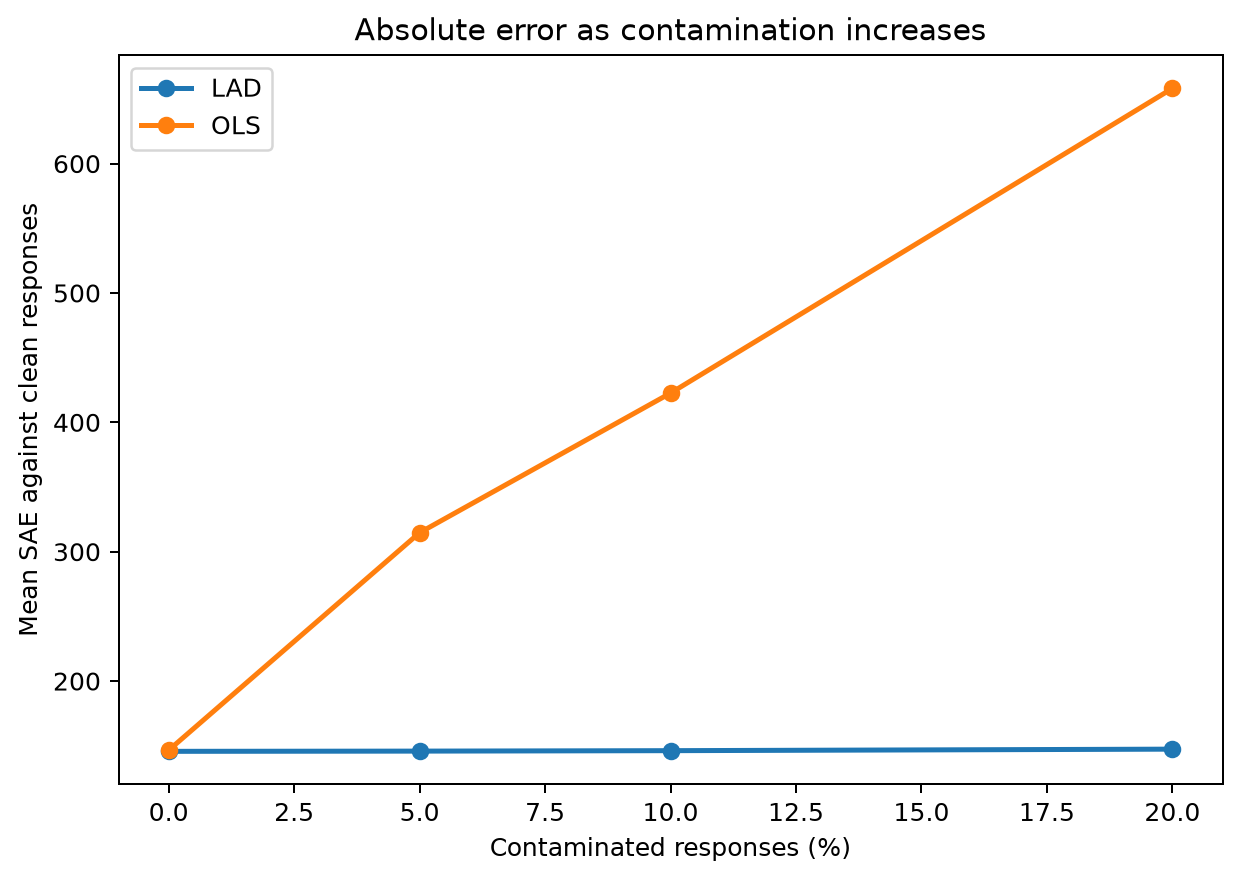

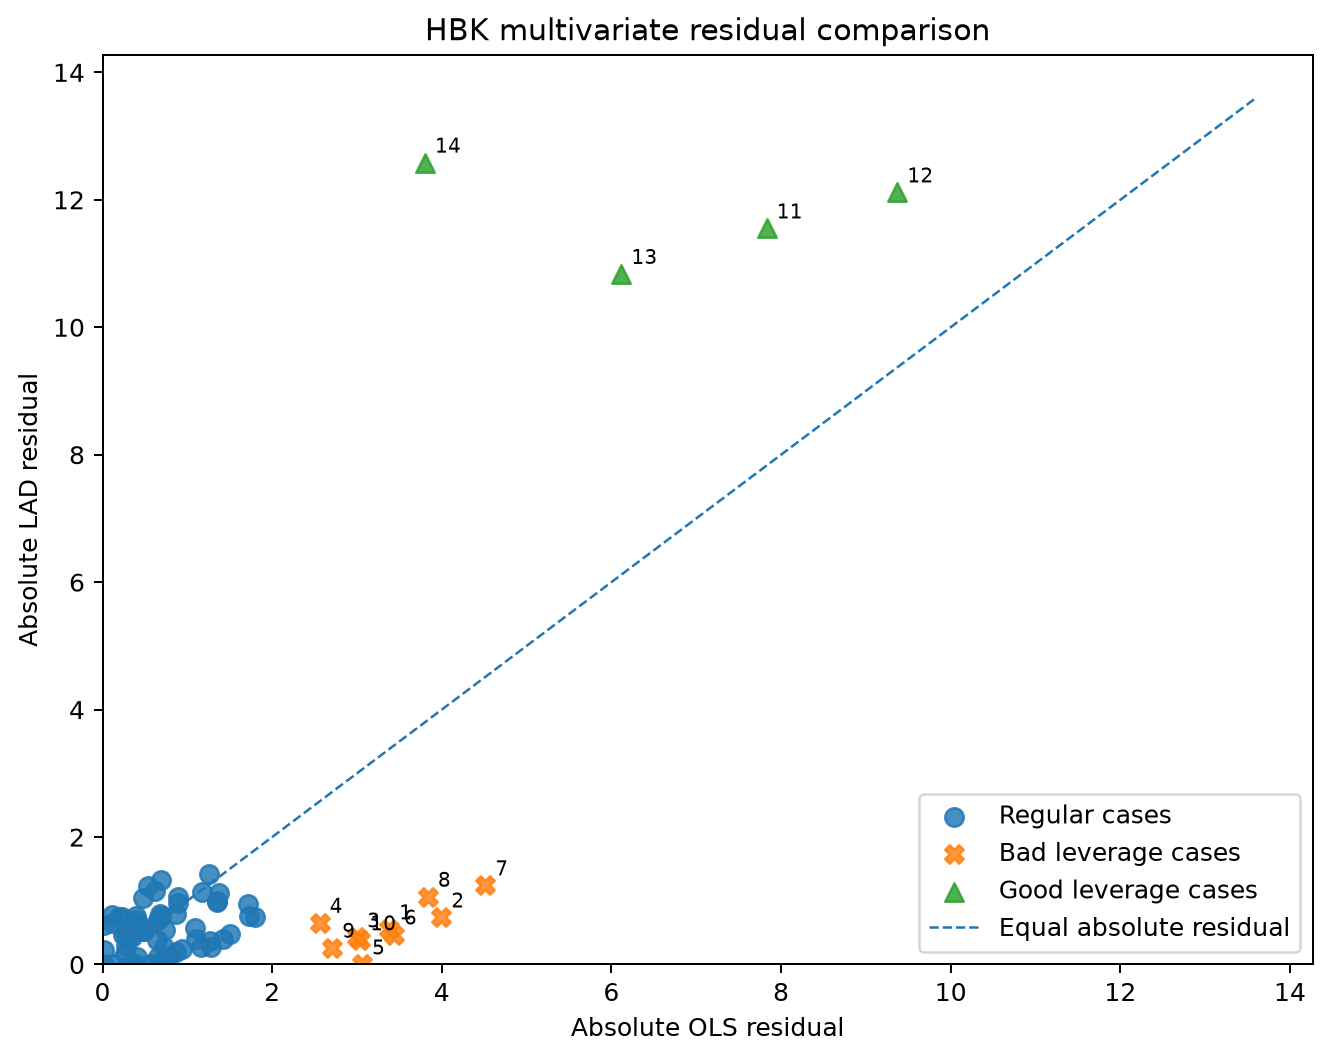

In [8]:
generate_all_figures()

key_figures = [
    "ols_lad_contaminated_fit.png",
    "sse_vs_contamination.png",
    "sae_vs_contamination.png",
    "hbk_multivariate_inlier_outlier.png",
]

for filename in key_figures:
    path = FIGURE_DIR / filename
    if path.exists():
        display(Image(filename=str(path)))


## 8. Generated files


In [9]:
result_files = sorted(path.name for path in RESULT_DIR.glob("*"))
figure_files = sorted(path.name for path in FIGURE_DIR.glob("*"))

display(pd.DataFrame({"result_files": pd.Series(result_files)}))
display(pd.DataFrame({"figure_files": pd.Series(figure_files)}))


,result_files
0,contamination_coefficient_changes.csv
1,contamination_metrics.csv
2,distribution_experiment.csv
3,lad_solver_validation.csv
4,original_data_coefficients.csv
5,original_data_metrics.csv
6,runtime_results.csv


,figure_files
0,hbk_multivariate_inlier_outlier.png
1,ols_lad_contaminated_fit.png
2,sae_vs_contamination.png
3,sse_vs_contamination.png


## 9. Summary

The empirical and controlled experiments compare OLS and LAD with the same observations and predictors. The final figures focus on the central distinction between squared-error and absolute-error minimization: how the fitted lines react to large response errors, how SSE and SAE change as contamination increases, and how the two regressions behave on the HBK dataset with its supplied case groups.
